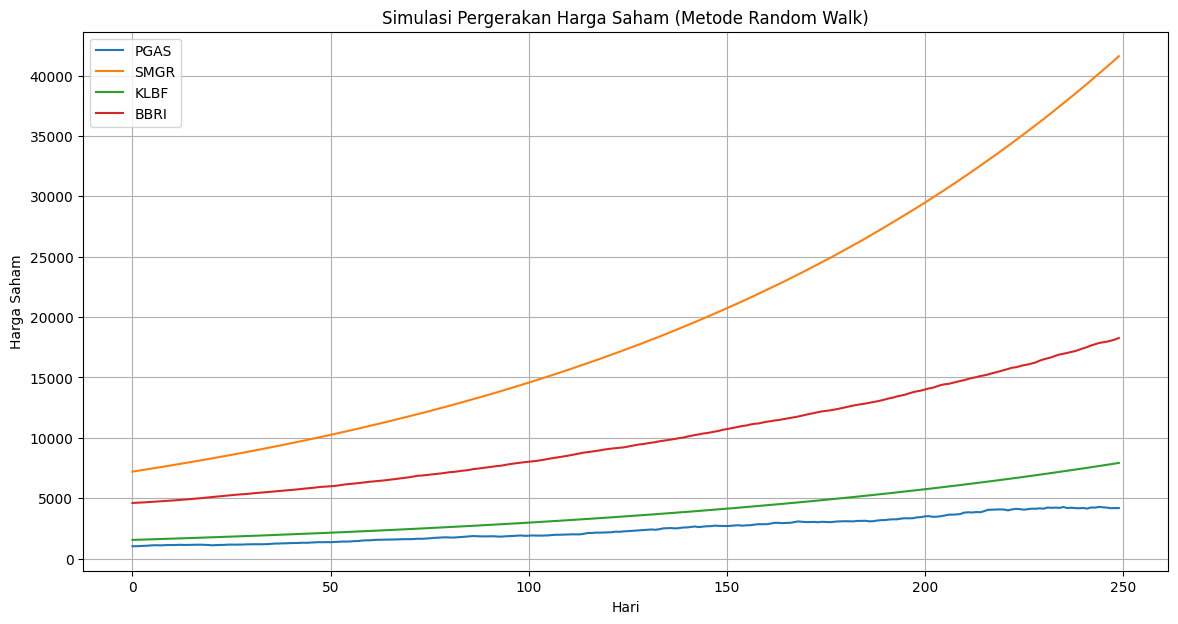

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fungsi untuk menghitung return harian
def calculate_daily_returns(prices):
    returns = prices.pct_change().dropna()
    return returns

# Fungsi untuk simulasi random walk
def random_walk_simulation(initial_price, days, drift, volatility):
    prices = [initial_price]
    for _ in range(days - 1):
        random_change = np.random.normal(drift, volatility)
        prices.append(prices[-1] * (1 + random_change))
    return prices

# Contoh data historis harga penutupan saham (misalnya, dari file CSV)
# data = pd.read_csv('data_historis.csv', parse_dates=['Date'], index_col='Date')

# Misalkan kita memiliki data historis dalam bentuk DataFrame
# Berikut adalah contoh data historis untuk ilustrasi
data = {
    'PGAS': [1000, 1010, 1025, 1030, 1020],  # Harga penutupan harian
    'SMGR': [7000, 7050, 7100, 7150, 7200],
    'KLBF': [1500, 1510, 1520, 1530, 1540],
    'BBRI': [4500, 4520, 4550, 4580, 4600]
}
historical_prices = pd.DataFrame(data)

# Menghitung return harian
returns = historical_prices.apply(calculate_daily_returns)

# Menghitung drift dan volatilitas
drift = returns.mean()
volatility = returns.std()

# Pengaturan simulasi
initial_prices = historical_prices.iloc[-1]  # Harga penutupan terakhir sebagai harga awal
sim_days = 250  # Jumlah hari untuk simulasi (misalnya, 1 tahun trading)

# Simulasi setiap saham
simulations = {}
for stock in historical_prices.columns:
    simulations[stock] = random_walk_simulation(
        initial_price=initial_prices[stock],
        days=sim_days,
        drift=drift[stock],
        volatility=volatility[stock]
    )

# Visualisasi hasil simulasi
plt.figure(figsize=(14, 7))
for stock, prices in simulations.items():
    plt.plot(prices, label=stock)

plt.title("Simulasi Pergerakan Harga Saham (Metode Random Walk)")
plt.xlabel("Hari")
plt.ylabel("Harga Saham")
plt.legend()
plt.grid()
plt.show()